In [1]:
import torch 
from typing import Optional, Dict
def pairwise_euclidean_distance(
    X: torch.Tensor,
    Y: Optional[torch.Tensor] = None,
    clip: bool = False,
    clip_value: float = 1000.0
) -> torch.Tensor:
    Y = X if Y is None else Y
    if clip:
        max_norm = torch.max(
            torch.abs(X).max() + torch.abs(Y).max(),
            torch.tensor(2 * clip_value, device=X.device, dtype=X.dtype)
        ) / 2
        X, Y = clip_value * X / max_norm, clip_value * Y / max_norm
    X_col, Y_row = X.unsqueeze(1), Y.unsqueeze(0)
    return torch.mean((X_col - Y_row) ** 2, dim=-1)

def Graph_weight(
    X: torch.Tensor,
    nearest_neighbor: int = 30,
    t: float = 1.0
) -> torch.Tensor:
    XX = X.detach()
    D = pairwise_euclidean_distance(XX, clip=True)
    values, indices = torch.topk(D, nearest_neighbor + 1, dim=1, largest=False)
    pos = D > values[:, nearest_neighbor].view(-1, 1)
    D[pos] = 0.0
    W = D * (D.T>0)
    index_pos = torch.where(W > 0)
    W_mean = torch.mean(W[index_pos])
    W[index_pos] = torch.exp(-W[index_pos] / (t * W_mean))
    return W

def pairwise_correlation_distance(
    X: torch.Tensor,
    Y: Optional[torch.Tensor] = None
) -> torch.Tensor:
    Y = X if Y is None else Y
    X_centered = X - X.mean(dim=1, keepdim=True)
    Y_centered = Y - Y.mean(dim=1, keepdim=True)
    cov = X_centered @ Y_centered.T
    std_X = torch.norm(X_centered, p=2, dim=1)
    std_Y = torch.norm(Y_centered, p=2, dim=1)
    corr = cov / (std_X.unsqueeze(1) * std_Y.unsqueeze(0) + 1e-8)
    return 1 - corr


def pairwise_euclidean_distance(
    X: torch.Tensor,
    Y: Optional[torch.Tensor] = None,
    clip: bool = False,
    clip_value: float = 1000.0
) -> torch.Tensor:
    Y = X if Y is None else Y
    if clip:
        max_norm = torch.max(
            torch.abs(X).max() + torch.abs(Y).max(),
            torch.tensor(2 * clip_value, device=X.device, dtype=X.dtype)
        ) / 2
        X, Y = clip_value * X / max_norm, clip_value * Y / max_norm
    X_col, Y_row = X.unsqueeze(1), Y.unsqueeze(0)
    return torch.mean((X_col - Y_row) ** 2, dim=-1)


def unbalanced_ot(
    cost_pp: torch.Tensor,
    reg: float = 0.05,
    reg_m: float = 0.5,
    prior: Optional[torch.Tensor] = None,
    device: str = 'cpu',
    max_iteration: Dict[str, int] = {'outer': 10, 'inner': 5}
) -> Optional[torch.Tensor]:
    ns, nt = cost_pp.shape
    if prior is not None:
        cost_pp = cost_pp * prior

    p_s = torch.ones(ns, 1, device=device) / ns
    p_t = torch.ones(nt, 1, device=device) / nt
    tran = torch.ones(ns, nt, device=device) / (ns * nt)
    dual = torch.ones(ns, 1, device=device) / ns
    f = reg_m / (reg_m + reg)

    for _ in range(max_iteration['outer']):
        cost = cost_pp
        kernel = torch.exp(-cost / (reg * torch.max(torch.abs(cost)))) * tran
        b = p_t / (torch.t(kernel) @ dual)
        for _ in range(max_iteration['inner']):
            dual = (p_s / (kernel @ b)) ** f
            b = (p_t / (torch.t(kernel) @ dual)) ** f
        tran = (dual @ torch.t(b)) * kernel

    out = tran.detach()
    return None if torch.isnan(out).sum() > 0 else out

def Graph_weight_smooth_P(
    P: torch.Tensor,
    W_A: torch.Tensor,
    W_B: torch.Tensor,
    alpha: float = 0.5
) -> torch.Tensor:
    I_A = torch.eye(W_A.size(0), device=W_A.device)
    I_B = torch.eye(W_B.size(0), device=W_B.device)
    P_hat = (I_A + alpha * W_A) @ P @ (I_B + alpha * W_B)
    return P_hat

In [2]:
z_1 = torch.rand(500, 10)
z_2 = torch.rand(500, 10)

In [3]:
c_cross = pairwise_correlation_distance(z_1, z_2)

In [35]:
P = unbalanced_ot(cost_pp=c_cross, reg=0.05, reg_m=0.5, max_iteration = {'outer': 10, 'inner': 5})  

In [22]:
P = P/P.max()

In [36]:
P.sum()

tensor(0.9041)

([<matplotlib.axis.XTick at 0x1c208478f40>,
 [Text(-3.5, 0, 'Overall score'),
  Text(-1.5, 0, 'Overall score\n(Batch correction)'),
  Text(5.5, 0, 'Overall score\n(Conservation of\nbiological variation)'),
  Text(0.0, 0, 'kBET'),
  Text(1.0, 0, 'Graph iLISI'),
  Text(2.0, 0, 'PCR batch'),
  Text(3.0, 0, 'Batch ASW'),
  Text(4.0, 0, 'Graph\nconnectivity'),
  Text(7.0, 0, 'ARI'),
  Text(8.0, 0, 'NMI'),
  Text(9.0, 0, 'Cell type ASW'),
  Text(10.0, 0, 'Graph cLISI'),
  Text(11.0, 0, 'Isolated label\nF1'),
  Text(12.0, 0, 'Isloated label\nsilhouette'),
  Text(13.0, 0, 'Cell cycle\nconservation')])

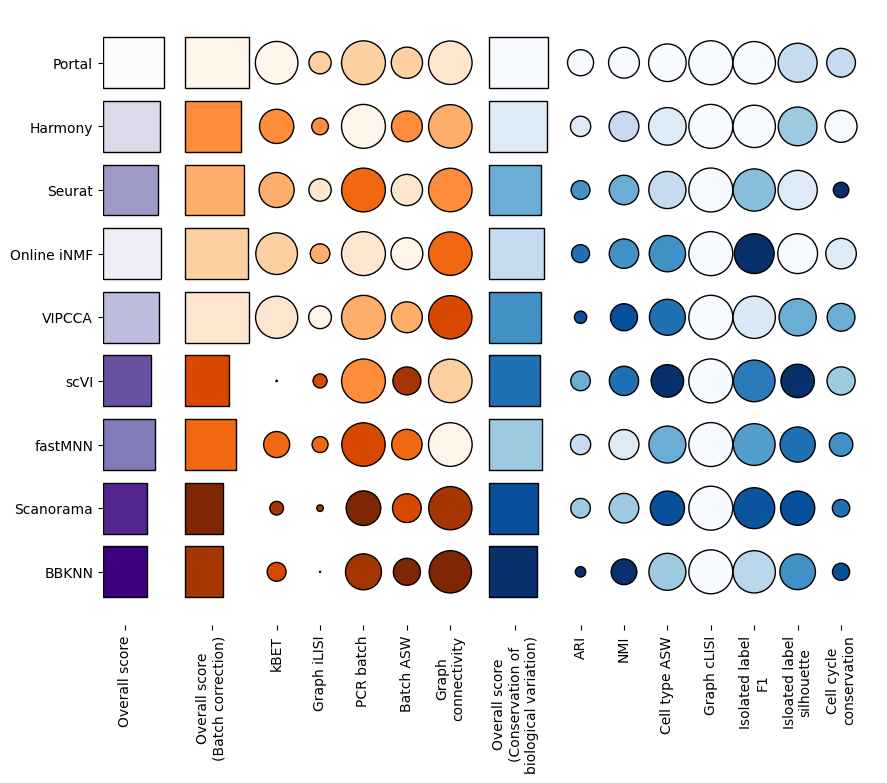

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
order = ["BBKNN", "Scanorama", "fastMNN", "scVI", "VIPCCA", "Online iNMF", "Seurat", "Harmony", "Portal"]
kbet_score = np.array([0.185, 0.097, 0.351, 0.001, 0.9195, 0.8985, 0.636, 0.607, 0.941])
kbet_rank = scipy.stats.rankdata(kbet_score, method='min')
kbet_rank = 10 - kbet_rank # larger is better

ilisi_score = np.array([0.000585, 0.022391, 0.133132, 0.102212, 0.267693, 0.198368, 0.258195, 0.14534, 0.255824])
ilisi_rank = scipy.stats.rankdata(ilisi_score, method='min')
ilisi_rank = 10 - ilisi_rank # larger is better

pcr_score = np.array([0.671196, 0.621043, 0.977809, 0.994272, 0.995944, 0.997139, 0.993321, 0.998409, 0.996014])
pcr_rank = scipy.stats.rankdata(pcr_score, method='min')
pcr_rank = 10 - pcr_rank # larger is better

batch_asw_score = np.array([0.378409, 0.4280735, 0.47885, 0.4056305, 0.4937195, 0.5251145, 0.5058415, 0.492221, 0.5054425])
batch_asw_rank = scipy.stats.rankdata(batch_asw_score, method='min')
batch_asw_rank = 10 - batch_asw_rank # larger is better

gconn_score = np.array([0.927946, 0.967705, 0.987162, 0.979829, 0.972187, 0.978945, 0.979144, 0.979182, 0.980028])
gconn_rank = scipy.stats.rankdata(gconn_score, method='min')
gconn_rank = 10 - gconn_rank # larger is better

ari_score = np.array([0.05555, 0.198669, 0.212494, 0.198655, 0.078371, 0.167216, 0.184786, 0.213591, 0.351073])
ari_rank = scipy.stats.rankdata(ari_score, method='min')
ari_rank = 10 - ari_rank # larger is better
                     
nmi_score = np.array([0.341581, 0.454461, 0.464057, 0.443687, 0.379208, 0.448948, 0.450711, 0.458651, 0.492576])
nmi_rank = scipy.stats.rankdata(nmi_score, method='min')
nmi_rank = 10 - nmi_rank # larger is better

asw_score = np.array([0.419558, 0.215414, 0.414396, 0.094833, 0.33863, 0.363257, 0.429482, 0.462064, 0.464374]) / 2 + 0.5
asw_rank = scipy.stats.rankdata(asw_score, method='min')
asw_rank = 10 - asw_rank # larger is better
                     
clisi_score = np.array([1., 1., 1., 1., 1., 1., 1., 1., 1.])
clisi_rank = scipy.stats.rankdata(clisi_score, method='min')
clisi_rank = 10 - clisi_rank # larger is better
                     
isof1_score = np.array([0.926338, 0.868496, 0.904455, 0.897748, 0.926986, 0.821378, 0.924538, 0.929152, 0.929152])
isof1_rank = scipy.stats.rankdata(isof1_score, method='min')
isof1_rank = 10 - isof1_rank # larger is better
                     
isoasw_score = np.array([0.655872, 0.606712, 0.641232, 0.57915, 0.714546, 0.82062, 0.798207, 0.774945, 0.784666])
isoasw_rank = scipy.stats.rankdata(isoasw_score, method='min')
isoasw_rank = 10 - isoasw_rank # larger is better
                     
cc_score = np.array([0.152588, 0.157718, 0.285003, 0.40949, 0.399832, 0.483516, 0.124312, 0.527718, 0.427455])
cc_rank = scipy.stats.rankdata(cc_score, method='min')
cc_rank = 10 - cc_rank # larger is better

batch_correct_score = (kbet_score + ilisi_score + pcr_score + batch_asw_score + gconn_score) / 5
batch_correct_rank = scipy.stats.rankdata(batch_correct_score, method='min')
batch_correct_score = np.clip(batch_correct_score, a_max = None, a_min = 0.001)
batch_correct_rank = 10 - batch_correct_rank # larger is better

bio_conserve_score = (ari_score + nmi_score + asw_score + 
    clisi_score + isof1_score + isoasw_score + cc_score) / 7
bio_conserve_rank = scipy.stats.rankdata(bio_conserve_score, method='min')
bio_conserve_score = np.clip(bio_conserve_score, a_max = None, a_min = 0.001)
bio_conserve_rank = 10 - bio_conserve_rank # larger is better

overall_score = (batch_correct_score * 0.4 + bio_conserve_score * 0.6)
overall_rank = scipy.stats.rankdata(overall_score, method='min')
overall_score = np.clip(overall_score, a_max = None, a_min = 0.001)
overall_rank = 10 - overall_rank # larger is better


plt.figure(figsize=(10,8))

plotsize = 1000
plt.box(False)

plt.scatter(np.zeros(9), order, s=kbet_score * plotsize, c = kbet_rank, cmap="Oranges", edgecolors="black")
plt.scatter(np.zeros(9) + 1, order, s=ilisi_score * plotsize, c = ilisi_rank, cmap="Oranges", edgecolors="black")
plt.scatter(np.zeros(9) + 2, order, s=pcr_score * plotsize, c = pcr_rank, cmap="Oranges", edgecolors="black")
plt.scatter(np.zeros(9) + 3, order, s=batch_asw_score * plotsize, c = batch_asw_rank, cmap="Oranges", edgecolors="black")
plt.scatter(np.zeros(9) + 4, order, s=gconn_score * plotsize, c = gconn_rank, cmap="Oranges", edgecolors="black")
plt.scatter(np.zeros(9) + 7, order, s=ari_score * plotsize, c = ari_rank, cmap="Blues", edgecolors="black")
plt.scatter(np.zeros(9) + 8, order, s=nmi_score * plotsize, c = nmi_rank, cmap="Blues", edgecolors="black")
plt.scatter(np.zeros(9) + 9, order, s=asw_score * plotsize, c = asw_rank, cmap="Blues", edgecolors="black")
plt.scatter(np.zeros(9) + 10, order, s=clisi_score * plotsize, c = clisi_rank, cmap="Blues", edgecolors="black")
plt.scatter(np.zeros(9) + 11, order, s=isof1_score * plotsize, c = isof1_rank, cmap="Blues", edgecolors="black")
plt.scatter(np.zeros(9) + 12, order, s=isoasw_score * plotsize, c = isoasw_rank, cmap="Blues", edgecolors="black")
plt.scatter(np.zeros(9) + 13, order, s=cc_score * plotsize, c = cc_rank, cmap="Blues", edgecolors="black")

batch_cmap = plt.get_cmap("Oranges")
bio_cmap = plt.get_cmap("Blues")
overall_cmap = plt.get_cmap("Purples")
rescale = lambda y: (y - np.min(y)) / (np.max(y) - np.min(y))

plt.barh(order, left=-2-0.1, width=batch_correct_score * 2, color=batch_cmap(rescale(batch_correct_rank)), edgecolor="black")
plt.barh(order, left=5-0.1, width=bio_conserve_score * 2, color=bio_cmap(rescale(bio_conserve_rank)), edgecolor="black")
plt.barh(order, left=-4, width=overall_score * 2, color=overall_cmap(rescale(overall_rank)), edgecolor="black")


plt.xticks([-3.5, -1.5, 5.5, 
    0, 1, 2, 3, 4, 
    7, 8, 9, 10, 11, 12, 13], 
    ['Overall score', 'Overall score\n(Batch correction)', 'Overall score\n(Conservation of\nbiological variation)',
    'kBET', 'Graph iLISI', 'PCR batch', 'Batch ASW', 'Graph\nconnectivity', 
    'ARI', 'NMI', 'Cell type ASW', 'Graph cLISI', 'Isolated label\nF1', 'Isloated label\nsilhouette',
    'Cell cycle\nconservation'], 
    rotation=90)

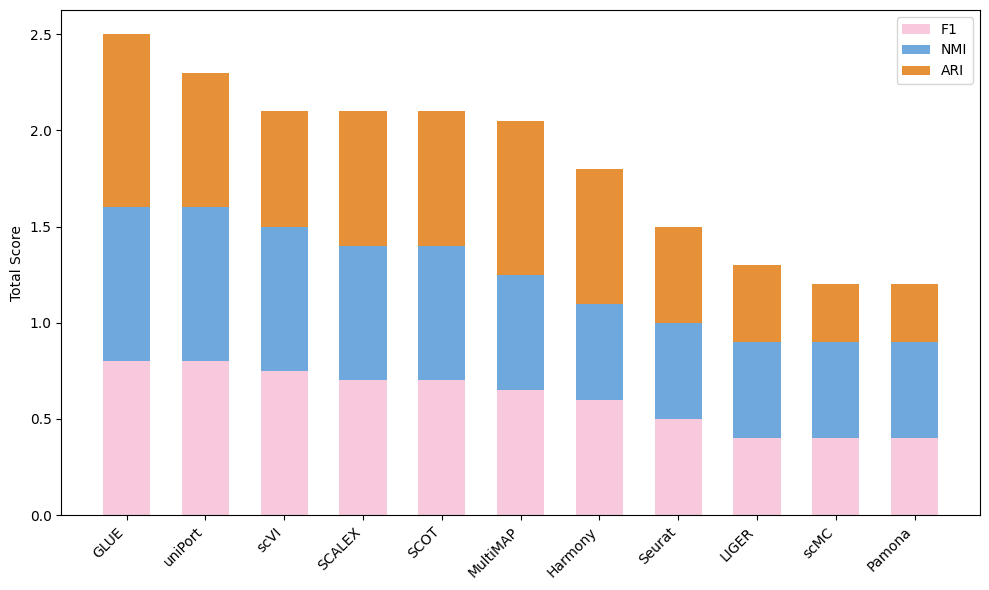

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 构造数据（用DataFrame存储）
data = {
    "Method": ["GLUE", "uniPort", "scVI", "SCALEX", "SCOT", "MultiMAP", "Harmony", "Seurat", "LIGER", "scMC", "Pamona"],
    "F1": [0.8, 0.8, 0.75, 0.7, 0.7, 0.65, 0.6, 0.5, 0.4, 0.4, 0.4],
    "NMI": [0.8, 0.8, 0.75, 0.7, 0.7, 0.6, 0.5, 0.5, 0.5, 0.5, 0.5],
    "ARI": [0.9, 0.7, 0.6, 0.7, 0.7, 0.8, 0.7, 0.5, 0.4, 0.3, 0.3]
}
df = pd.DataFrame(data)

# 2. 设置绘图参数
plt.figure(figsize=(10, 6))
x = np.arange(len(df["Method"]))  # x轴位置
width = 0.6  # 柱子宽度

# 3. 绘制堆叠柱（按F1→NMI→ARI的顺序，后一个的bottom是前几个的和）
p1 = plt.bar(x, df["F1"], width, label="F1", color="#F8C8DC")  # 粉色（对应图中F1）
p2 = plt.bar(x, df["NMI"], width, bottom=df["F1"], label="NMI", color="#6FA8DC")  # 蓝色（对应图中NMI）
p3 = plt.bar(x, df["ARI"], width, bottom=df["F1"] + df["NMI"], label="ARI", color="#E69138")  # 橙色（对应图中ARI）

# 4. 添加图表元素
plt.ylabel("Total Score")
plt.xticks(x, df["Method"], rotation=45, ha="right")  # 旋转x轴标签避免重叠
plt.legend()
plt.tight_layout()  # 自动调整布局

# 5. 显示/保存图
plt.show()
# plt.savefig("stacked_bar.png", dpi=300)